In [ ]:
from glob import glob
import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

import cartopy.crs as ccrs
import seaborn as sns

sns.set_style('whitegrid')

# Introduction

Data shared contains **storm surge annual maxima data based on the DCPP simulations**. The folder contains 8 netcdf files, containing the data from 8 different models. 

Data is stored using **xarray**, which allows metadata, labels, and coordinates to be embedded directly in the files. As a result, the dataset should be largely self-explanatory and relatively easy to explore.

At each grid point (~ coastal site), there are **three possible bias corrections**: 
- coordinate *bc_flag indicates which bias correction should be used at each grid point*. 
- coordinate *model_valid* indicates whether the data from the model should be considered reliable at a given grid point.

Below, I have included a few simple examples showing how to interrogate the xarray Dataset and extract the data you may need, for convenience.


**Background information on the DCPP simulations**
  * https://confluence.ecmwf.int/display/CKB/CMIP6%3A+Decadal+climate+predictions




**linked packages**
  * https://docs.xarray.dev/en/stable/index.html

# Settings

In [130]:
# color palette finder https://python-graph-gallery.com/color-palette-finder/
colors = ['#7FF9F7FF', '#0B2483FF','#0F8CDEFF','#4C4CFFFF','#040509FF','#23B4DCFF','#3C7084FF']

# Loading data

In [131]:
path = '../../input/Annual_max_DCPP_20260112/'

In [132]:
ls_files = [file for file in glob(path + '*.nc')]
ls_files

['../../input/Annual_max_DCPP_20260112/Annual_max_MIROC6.nc',
 '../../input/Annual_max_DCPP_20260112/Annual_max_MPI-ESM1-2-HR.nc',
 '../../input/Annual_max_DCPP_20260112/Annual_max_HadGEM3-GC31-MM.nc',
 '../../input/Annual_max_DCPP_20260112/Annual_max_MRI-ESM2-0.nc',
 '../../input/Annual_max_DCPP_20260112/Annual_max_BCC-CSM2-MR.nc',
 '../../input/Annual_max_DCPP_20260112/Annual_max_CMCC-CM2-SR5.nc',
 '../../input/Annual_max_DCPP_20260112/Annual_max_CanESM5.nc',
 '../../input/Annual_max_DCPP_20260112/Annual_max_NorCPM1.nc']

In [14]:
file = ls_files[0]

In [17]:
model_name = file.split('/')[-1].split('Annual_max_')[-1].split('.')[0]
model_name

'MIROC6'

In [6]:
ds = xr.open_dataset(file, engine="netcdf4")

# Data Structure

In [11]:
ds

<xarray.Dataset> Size: 360MB
Dimensions:      (sample: 680, member: 2, bc: 3, sites: 11022)
Coordinates:
  * sample       (sample) int64 5kB 0 1 2 3 4 5 6 ... 674 675 676 677 678 679
  * member       (member) int64 16B 1 2
  * bc           (bc) int64 24B 1 2 3
  * sites        (sites) int64 88kB 0 1 2 3 4 ... 11017 11018 11019 11020 11021
    sim_year     (sample) float64 5kB ...
    lead         (sample) float64 5kB ...
    lon          (sites) float64 88kB ...
    lat          (sites) float64 88kB ...
    bc_flag      (sites) uint8 11kB ...
    model_valid  (sites) bool 11kB ...
Data variables:
    annualMax    (sample, member, bc, sites) float64 360MB ...
Attributes:
    description:  Modelled storm-surge annual maxima organized by simulated y...
    model:        MIROC6

In [7]:
ds["annualMax"].attrs

{'long_name': 'Storm-surge annual maxima', 'units': 'm'}

In [78]:
ds.sample.sim_year == 2020

<xarray.DataArray 'sim_year' (sample: 680)> Size: 680B
array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
...
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False])
Coordinates:
  * sample    (sample) int64 5kB 0 1 2 3 4 5 6 7 ... 673 674 675 676 677 678 679
    sim_year  (sample) float64 5kB 1.961e+03 1.961e+03 ... 2.028e+03 2.028e+03
    lead      (sample) float64 5kB 1.0 2.0 3.0 4.0 5.0 ... 6.0 7.0 8.0 9.0 10.0

In [36]:
ds['sites']

<xarray.DataArray 'sites' (sites: 11022)> Size: 88kB
array([    0,     1,     2, ..., 11019, 11020, 11021], shape=(11022,))
Coordinates:
  * sites        (sites) int64 88kB 0 1 2 3 4 ... 11017 11018 11019 11020 11021
    lon          (sites) float64 88kB ...
    lat          (sites) float64 88kB ...
    bc_flag      (sites) uint8 11kB ...
    model_valid  (sites) bool 11kB ...

In [45]:
ds["bc_flag"].astype(int)-1

<xarray.DataArray 'bc_flag' (sites: 11022)> Size: 88kB
array([2, 2, 2, ..., 1, 1, 1], shape=(11022,))
Coordinates:
  * sites        (sites) int64 88kB 0 1 2 3 4 ... 11017 11018 11019 11020 11021
    lon          (sites) float64 88kB ...
    lat          (sites) float64 88kB ...
    bc_flag      (sites) uint8 11kB ...
    model_valid  (sites) bool 11kB ...

# Example Usage 

### Selecting Bias Correction

In [46]:
bc_index = ds["bc_flag"].astype(int) - 1  # (sites,)

annualMax_pref = xr.apply_ufunc(
    lambda v, i: v[i],
    ds["annualMax"],
    bc_index,
    input_core_dims=[["bc"], []],
    output_core_dims=[[]],
    vectorize=True,
    dask="allowed",
    output_dtypes=[ds["annualMax"].dtype],
)

In [ ]:
annualMax_pref

<xarray.DataArray 'annualMax' (sample: 680, member: 2, sites: 11022)> Size: 120MB
array([[[0.89560395, 0.90559137, 0.91389578, ..., 1.57541691,
         1.57917887, 1.57760778],
        [0.65744602, 0.66069273, 0.66074743, ..., 1.31545594,
         1.34090255, 1.345234  ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       ...,

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[0.67042736, 0.67181457, 0.66898944, ..., 1.49595415,
         1.52054261, 1.52088365],
        [0.68127764, 0.68580865, 0.68651991, ..., 1.39821734,
         1.3986829 , 1.39364247]]], shape=(680, 2, 11022))
Coordinates:
  * sample       (sample) int64 5kB 0 1 2 3 4 5 6 ... 674 675 676 677 678 679
  * member       (member) int64 16B 1 2
  * sites        (sites) int64 88kB 0 1 2 3 4 ... 11017 11018 11019 11020 11021
    sim_year     (sample) float64 5kB ...
    lead         (sample) float64 5kB ...
    lon          (sites) float64 88kB 9.397 9.73 9.934 ... 3.791 3.768 3.74
    lat          (sites) float64 88kB 64.37 64.34 64.31 ... 51.64 51.65 51.65
    bc_flag      (sites) uint8 11kB 3 3 3 3 3 3 3 3 3 3 ... 2 2 2 2 2 2 2 2 2 2
    model_valid  (sites) bool 11kB True True True True ... False False True True
Attributes:
    long_name:  Storm-surge annual maxima
    units:      m

### Extract all annual maxima for a given simulated year (all ensemble members, all lead years)

In [ ]:
year = 1980
am_1980 = annualMax_pref.where(ds.sim_year == year, drop=True)

am_1980

<xarray.DataArray 'annualMax' (sample: 10, member: 2, sites: 11022)> Size: 2MB
array([[[0.57154   , 0.57279404, 0.57074856, ..., 1.19274976,
         1.20148448, 1.19456577],
        [0.93338553, 0.95046383, 0.95307449, ..., 1.28096979,
         1.29595402, 1.29313472]],

       [[0.78274302, 0.7921074 , 0.79593393, ..., 1.42977558,
         1.43519512, 1.43000758],
        [0.62526045, 0.62497655, 0.62473364, ..., 1.55125314,
         1.56011234, 1.55789524]],

       [[0.66726597, 0.67582189, 0.67497484, ..., 1.65118601,
         1.6788996 , 1.69099914],
        [0.54760871, 0.54957853, 0.54867505, ..., 1.53948695,
         1.55190766, 1.5482507 ]],

       ...,

       [[0.89370243, 0.901656  , 0.8996903 , ..., 1.25145189,
         1.2496992 , 1.24229371],
        [0.77278003, 0.78140277, 0.78456791, ..., 1.3357946 ,
         1.34357587, 1.34657333]],

       [[0.76021877, 0.77503503, 0.77888535, ..., 1.24441546,
         1.25811113, 1.25980721],
        [0.87494759, 0.87318131, 0.86270706, ..., 1.29740571,
         1.29989311, 1.29276333]],

       [[0.76848756, 0.77472506, 0.77311736, ..., 1.51311316,
         1.53668409, 1.53668002],
        [0.89624987, 0.9081484 , 0.9144745 , ..., 1.61397728,
         1.62031356, 1.61289464]]], shape=(10, 2, 11022))
Coordinates:
  * sample       (sample) int64 80B 190 191 192 193 194 195 196 197 198 199
  * member       (member) int64 16B 1 2
  * sites        (sites) int64 88kB 0 1 2 3 4 ... 11017 11018 11019 11020 11021
    sim_year     (sample) float64 80B 1.98e+03 1.98e+03 ... 1.98e+03 1.98e+03
    lead         (sample) float64 80B 1.0 2.0 3.0 4.0 5.0 6.0 7.0 8.0 9.0 10.0
    lon          (sites) float64 88kB 9.397 9.73 9.934 ... 3.791 3.768 3.74
    lat          (sites) float64 88kB 64.37 64.34 64.31 ... 51.64 51.65 51.65
    bc_flag      (sites) uint8 11kB 3 3 3 3 3 3 3 3 3 3 ... 2 2 2 2 2 2 2 2 2 2
    model_valid  (sites) bool 11kB True True True True ... False False True True
Attributes:
    long_name:  Storm-surge annual maxima
    units:      m

### Extract year + specific lead year

In [56]:
year = 1980
lead = 3
am_1980_l3 = annualMax_pref.where(
    (ds.sim_year == year) & (ds.lead == lead),
    drop=True
)

am_1980_l3

<xarray.DataArray 'annualMax' (sample: 1, member: 2, sites: 11022)> Size: 176kB
array([[[0.66726597, 0.67582189, 0.67497484, ..., 1.65118601,
         1.6788996 , 1.69099914],
        [0.54760871, 0.54957853, 0.54867505, ..., 1.53948695,
         1.55190766, 1.5482507 ]]], shape=(1, 2, 11022))
Coordinates:
  * sample       (sample) int64 8B 192
  * member       (member) int64 16B 1 2
  * sites        (sites) int64 88kB 0 1 2 3 4 ... 11017 11018 11019 11020 11021
    sim_year     (sample) float64 8B 1.98e+03
    lead         (sample) float64 8B 3.0
    lon          (sites) float64 88kB 9.397 9.73 9.934 ... 3.791 3.768 3.74
    lat          (sites) float64 88kB 64.37 64.34 64.31 ... 51.64 51.65 51.65
    bc_flag      (sites) uint8 11kB 3 3 3 3 3 3 3 3 3 3 ... 2 2 2 2 2 2 2 2 2 2
    model_valid  (sites) bool 11kB True True True True ... False False True True
Attributes:
    long_name:  Storm-surge annual maxima
    units:      m

### Extract time series at one site (all years and leads)

In [55]:
site_id = 5000
am_site = annualMax_pref.isel(sites=site_id)
ti = am_site['sim_year'].values
lyr = am_site['lead'].values
ami = am_site.values


# Display Model Locations 
Which locations are we looking at? which one are valid?

In [133]:
df = pd.DataFrame([ds.lon.values, ds.lat.values, ds.model_valid.values], index=['lon', 'lat', 'model_valid']).T
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11022 entries, 0 to 11021
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   lon          11022 non-null  object
 1   lat          11022 non-null  object
 2   model_valid  11022 non-null  object
dtypes: object(3)
memory usage: 258.5+ KB


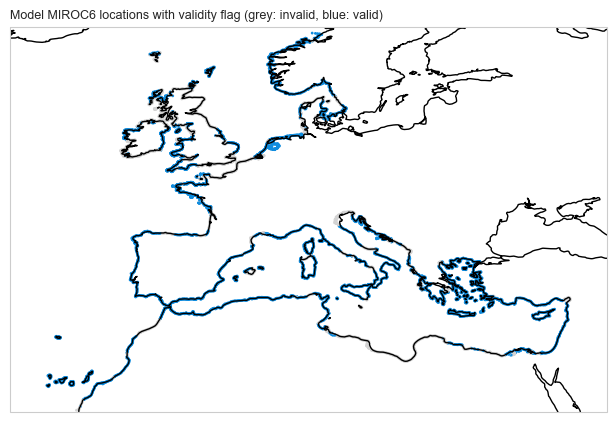

In [ ]:
fig, ax = plt.subplots(
    figsize=(8, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
)
ax.set_title(
    f"Model {model_name} locations with validity flag (grey: invalid, blue: valid)", 
    loc='left', 
    fontsize=9
    )


cmap = ListedColormap(["lightgrey", colors[2]])
norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

ax.scatter(
    df["lon"],
    df["lat"],
    c=df["model_valid"].astype(int),
    s=1,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree(),
)
ax.coastlines()
ax.set_extent([-22, 40, 25, 65], crs=ccrs.PlateCarree()) 

plt.show()

# Display Timeseries at a specific location

In [ ]:
site_id = 5000
am_site = annualMax_pref.isel(sites=site_id)
ti = am_site['sim_year'].values
lyr = am_site['lead'].values
ami = am_site.values